#Dataset link : https://drive.google.com/drive/folders/1PrO_ZBiYM9hmMQIdgqt7otH0886pO7Xr?usp=sharing
# Part 6: Performance Evaluation, Ablation Study & Error Analysis

**Sections:**
1. Per-class precision, recall, F1 for all models
2. Normalised confusion matrices
3. AUC-ROC per class
4. 5-seed stability evaluation
5. Final results table (mean ± std)
6. Ablation study — feature groups
7. Error analysis — misclassified examples
8. Literature comparison

In [4]:
import torch
print(f'CUDA available    : {torch.cuda.is_available()}')
print(f'CUDA device count : {torch.cuda.device_count()}')
print(f'Current device    : {torch.cuda.current_device() if torch.cuda.is_available() else "N/A"}')
print(f'Device name       : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"}')
#print(f'DEVICE variable   : {DEVICE}')

# Check if torch was installed with CUDA support
print(f'\nTorch version     : {torch.__version__}')
print(f'Torch CUDA build  : {torch.version.cuda}')
from google.colab import drive
drive.mount('/content/drive')

CUDA available    : True
CUDA device count : 1
Current device    : 0
Device name       : Tesla T4

Torch version     : 2.10.0+cu128
Torch CUDA build  : 12.8
Mounted at /content/drive


---
## 0. Imports & Load All Results

In [5]:
import os, json, pickle, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as tv_models

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE     = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
CLASS_NAMES = ['Motorboats','Mussel Boats','Fishing Vessels',
               'Passengers/Ferries','Ocean Liners/Tugboats']
N_CLASSES   = 5
FEAT_DIR    = '/content/drive/MyDrive/ShipsEar Dataset/features'
MODEL_DIR   = '/content/drive/MyDrive/ShipsEar Dataset/models'
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE  = 32

# ── Load features ────────────────────────────────────────────────────────────
X_train = np.load(f'{FEAT_DIR}/features_train.npy')
X_val   = np.load(f'{FEAT_DIR}/features_val.npy')
X_test  = np.load(f'{FEAT_DIR}/features_test.npy')
y_train = np.load(f'{FEAT_DIR}/labels_train.npy')
y_val   = np.load(f'{FEAT_DIR}/labels_val.npy')
y_test  = np.load(f'{FEAT_DIR}/labels_test.npy')

X_spec_train = np.load(f'{FEAT_DIR}/spec_train.npy')
X_spec_val   = np.load(f'{FEAT_DIR}/spec_val.npy')
X_spec_test  = np.load(f'{FEAT_DIR}/spec_test.npy')
y_spec_train = np.load(f'{FEAT_DIR}/spec_labels_train.npy')
y_spec_val   = np.load(f'{FEAT_DIR}/spec_labels_val.npy')
y_spec_test  = np.load(f'{FEAT_DIR}/spec_labels_test.npy')

# ── Load per-group features for ablation ────────────────────────────────────
FEAT_GROUPS = ['mfcc', 'stft', 'lofar', 'demon']
X_groups_train = {g: np.load(f'{FEAT_DIR}/feat_{g}_train.npy') for g in FEAT_GROUPS}
X_groups_val   = {g: np.load(f'{FEAT_DIR}/feat_{g}_val.npy')   for g in FEAT_GROUPS}
X_groups_test  = {g: np.load(f'{FEAT_DIR}/feat_{g}_test.npy')  for g in FEAT_GROUPS}

# ── Load saved classical models ──────────────────────────────────────────────
with open(f'{MODEL_DIR}/knn_best.pkl',     'rb') as f: knn_model = pickle.load(f)
with open(f'{MODEL_DIR}/svm_rbf_best.pkl', 'rb') as f: svm_model = pickle.load(f)
with open(f'{MODEL_DIR}/rf_best.pkl',      'rb') as f: rf_model  = pickle.load(f)

print(f'Device : {DEVICE}')
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')
print(f'Spec test: {X_spec_test.shape}')
print('All data and models loaded ✓')

Device : cuda
X_train: (1389, 334)  y_train: (1389,)
X_test : (445, 334)   y_test : (445,)
Spec test: (445, 1, 128, 128)
All data and models loaded ✓


## 1. Re-define Model Architectures & Load Weights

In [6]:
# ── CNN architecture (non-inplace ReLU for GradCAM compatibility) ─────────────
class ShipsEarCNN(nn.Module):
    def __init__(self, n_classes=5, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(inplace=False), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(inplace=False), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(inplace=False), nn.MaxPool2d(2, 2),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128, 256),
            nn.ReLU(inplace=False), nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))

class ResNet18ShipsEar(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        backbone = tv_models.resnet18(weights=None)
        backbone.fc = nn.Linear(backbone.fc.in_features, n_classes)
        self.backbone = backbone
    def forward(self, x):
        return self.backbone(x.repeat(1, 3, 1, 1))

# Load weights
cnn_model = ShipsEarCNN(N_CLASSES).to(DEVICE)
cnn_model.load_state_dict(
    {k: v.to(DEVICE) for k, v in
     torch.load(f'{MODEL_DIR}/cnn_scratch.pth', map_location=DEVICE).items()}
)
cnn_model.eval()

resnet_model = ResNet18ShipsEar(N_CLASSES).to(DEVICE)
resnet_model.load_state_dict(
    {k: v.to(DEVICE) for k, v in
     torch.load(f'{MODEL_DIR}/resnet18_finetuned.pth', map_location=DEVICE).items()}
)
resnet_model.eval()
print('CNN and ResNet-18 weights loaded ✓')

# Dataset class
class SpectrogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor((X + 80.0) / 80.0)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

test_dataset = SpectrogramDataset(X_spec_test, y_spec_test)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def dl_predict(model, loader):
    model.eval()
    preds, probs = [], []
    with torch.no_grad():
        for X_b, _ in loader:
            X_b = X_b.to(DEVICE)
            out = model(X_b)
            probs.extend(torch.softmax(out, 1).cpu().numpy())
            preds.extend(out.argmax(1).cpu().numpy())
    return np.array(preds), np.array(probs)

cnn_pred, cnn_prob   = dl_predict(cnn_model,    test_loader)
rn_pred,  rn_prob    = dl_predict(resnet_model, test_loader)
knn_pred = knn_model.predict(X_test)
svm_pred = svm_model.predict(X_test)
rf_pred  = rf_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)
svm_prob = svm_model.predict_proba(X_test)
rf_prob  = rf_model.predict_proba(X_test)

print('All predictions generated ✓')

CNN and ResNet-18 weights loaded ✓
All predictions generated ✓


In [7]:
# Pool everything and do a clean stratified split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_all_raw   = np.concatenate([
    np.load('/content/drive/MyDrive/ShipsEar Dataset/features/feat_mfcc_train.npy'),
    np.load('/content/drive/MyDrive/ShipsEar Dataset/features/feat_mfcc_val.npy'),
    np.load('/content/drive/MyDrive/ShipsEar Dataset/features/feat_mfcc_test.npy')
], axis=0)

# Actually easier — just pool the scaled full features + labels
X_pool = np.concatenate([X_train, X_val, X_test])
y_pool = np.concatenate([y_train, y_val, y_test])

print('All classes in pool:', np.unique(y_pool, return_counts=True))

# 70/15/15 stratified split
X_tv, X_test_new, y_tv, y_test_new = train_test_split(
    X_pool, y_pool, test_size=0.15, stratify=y_pool, random_state=42
)
X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
    X_tv, y_tv, test_size=0.176, stratify=y_tv, random_state=42
)

print(f'Train: {len(y_train_new)} | classes: {np.unique(y_train_new).tolist()}')
print(f'Val  : {len(y_val_new)}   | classes: {np.unique(y_val_new).tolist()}')
print(f'Test : {len(y_test_new)}  | classes: {np.unique(y_test_new).tolist()}')

# Retrain and re-evaluate all classical models
X_train, X_val, X_test = X_train_new, X_val_new, X_test_new
y_train, y_val, y_test = y_train_new, y_val_new, y_test_new

knn_model.fit(X_train, y_train); knn_pred = knn_model.predict(X_test); knn_prob = knn_model.predict_proba(X_test)
svm_model.fit(X_train, y_train); svm_pred = svm_model.predict(X_test); svm_prob = svm_model.predict_proba(X_test)
rf_model.fit(X_train, y_train);  rf_pred  = rf_model.predict(X_test);  rf_prob  = rf_model.predict_proba(X_test)

print('\nAfter resplit:')
print(f'  KNN prob shape: {knn_prob.shape}')   # should be (N, 5)

All classes in pool: (array([0, 1, 2, 3, 4]), array([369, 301, 843, 486, 224]))
Train: 1556 | classes: [0, 1, 2, 3, 4]
Val  : 333   | classes: [0, 1, 2, 3, 4]
Test : 334  | classes: [0, 1, 2, 3, 4]

After resplit:
  KNN prob shape: (334, 5)


---
## 2. Per-Class Precision, Recall & F1

In [8]:
models = [
    ('KNN',       y_test,      knn_pred, knn_prob),
    ('SVM RBF',   y_test,      svm_pred, svm_prob),
    ('Random Forest', y_test,  rf_pred,  rf_prob),
    ('CNN (scratch)', y_spec_test, cnn_pred, cnn_prob),
    ('ResNet-18',     y_spec_test, rn_pred,  rn_prob),
]

print('='*80)
print('PER-CLASS CLASSIFICATION REPORTS — ALL MODELS')
print('='*80)

for name, y_true, y_pred, _ in models:
    print(f'\n--- {name} ---')
    print(classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        zero_division=0, digits=4
    ))
    # Hardest class
    report = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES,
        zero_division=0, output_dict=True
    )
    f1s = {cn: report[cn]['f1-score'] for cn in CLASS_NAMES}
    print(f'  Hardest class: {min(f1s, key=f1s.get)} (F1={min(f1s.values()):.4f})')

PER-CLASS CLASSIFICATION REPORTS — ALL MODELS

--- KNN ---
                       precision    recall  f1-score   support

           Motorboats     0.8136    0.8727    0.8421        55
         Mussel Boats     0.7619    0.7111    0.7356        45
      Fishing Vessels     0.9217    0.8346    0.8760       127
   Passengers/Ferries     0.8148    0.9041    0.8571        73
Ocean Liners/Tugboats     0.8919    0.9706    0.9296        34

             accuracy                         0.8533       334
            macro avg     0.8408    0.8586    0.8481       334
         weighted avg     0.8560    0.8533    0.8529       334

  Hardest class: Mussel Boats (F1=0.7356)

--- SVM RBF ---
                       precision    recall  f1-score   support

           Motorboats     0.9091    0.9091    0.9091        55
         Mussel Boats     0.8780    0.8000    0.8372        45
      Fishing Vessels     0.9051    0.9764    0.9394       127
   Passengers/Ferries     0.9710    0.9178    0.9437       

## 3. Normalised Confusion Matrices — All Models

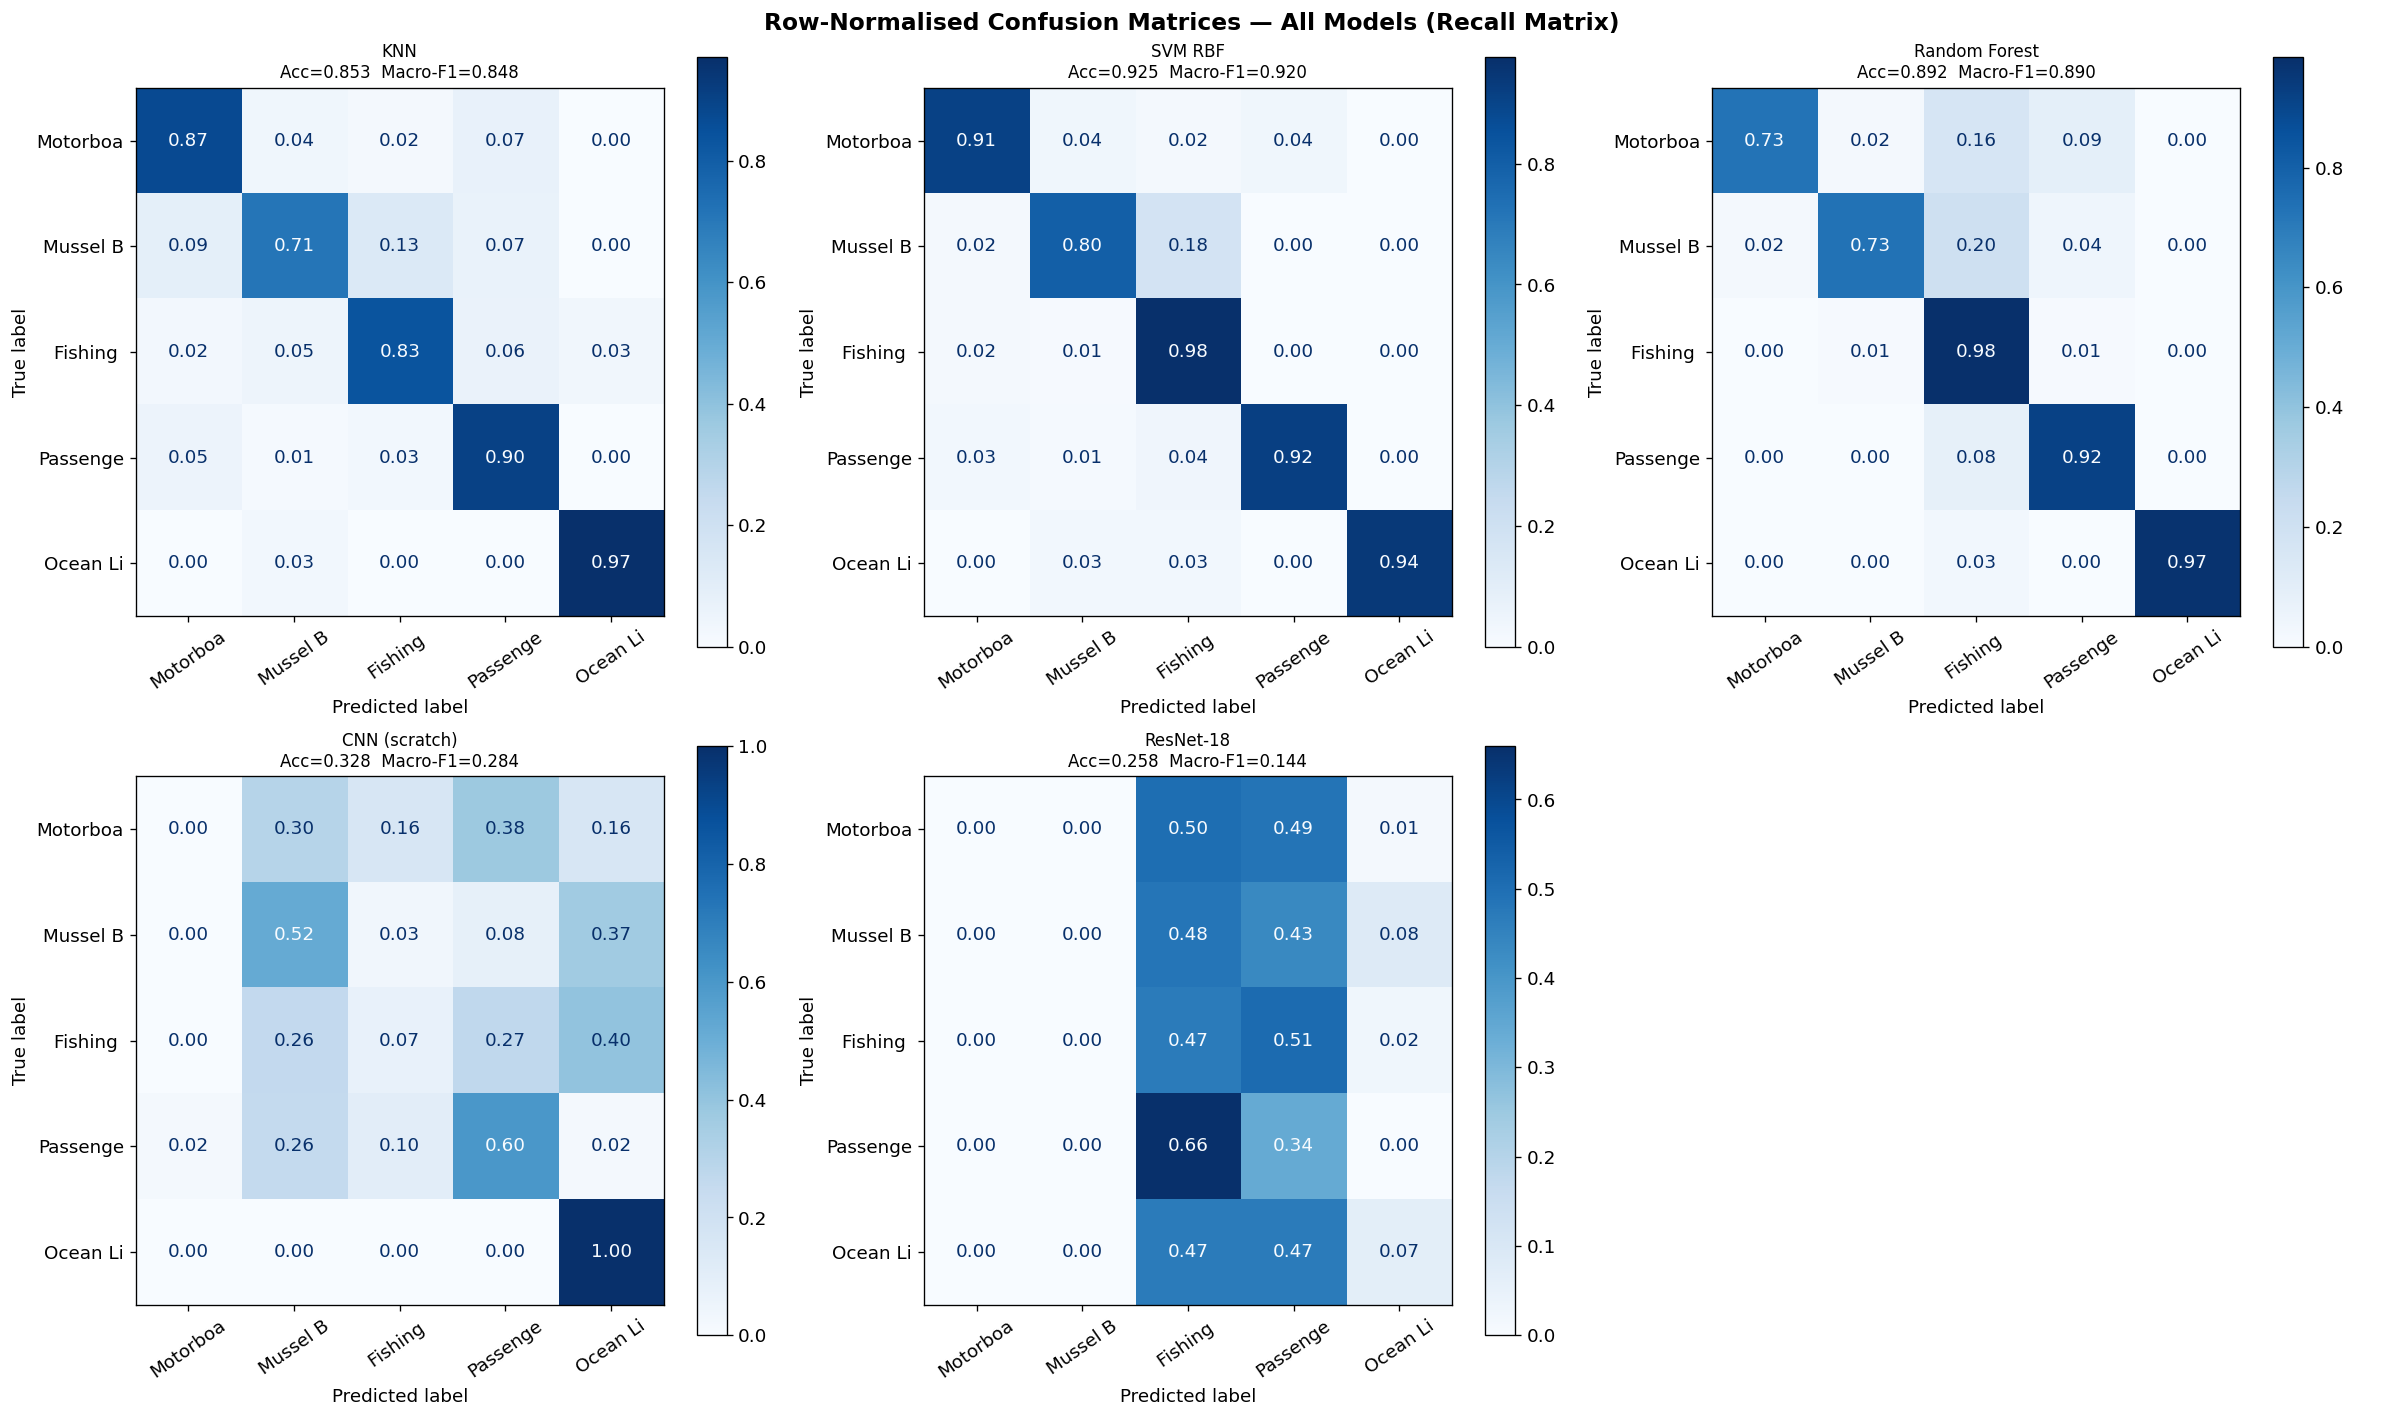


Most confused class pairs per model:
  KNN                 : Mussel Boats → predicted as Fishing Vessels (13.3% of Mussel Boats misclassified)
  SVM RBF             : Mussel Boats → predicted as Fishing Vessels (17.8% of Mussel Boats misclassified)
  Random Forest       : Mussel Boats → predicted as Fishing Vessels (20.0% of Mussel Boats misclassified)
  CNN (scratch)       : Fishing Vessels → predicted as Ocean Liners/Tugboats (40.2% of Fishing Vessels misclassified)
  ResNet-18           : Passengers/Ferries → predicted as Fishing Vessels (66.0% of Passengers/Ferries misclassified)


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
short = [n[:8] for n in CLASS_NAMES]

for ax, (name, y_true, y_pred, _) in zip(axes, models):
    cm   = confusion_matrix(y_true, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=short)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    ax.set_title(f'{name}\nAcc={acc:.3f}  Macro-F1={f1:.3f}', fontsize=10)
    ax.tick_params(axis='x', rotation=35)

axes[-1].axis('off')  # hide 6th panel
plt.suptitle('Row-Normalised Confusion Matrices — All Models (Recall Matrix)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_all_confusion_matrices.png', bbox_inches='tight')
plt.show()

# Most confused pairs
print('\nMost confused class pairs per model:')
for name, y_true, y_pred, _ in models:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    np.fill_diagonal(cm, 0)
    i, j = np.unravel_index(cm.argmax(), cm.shape)
    print(f'  {name:<20s}: {CLASS_NAMES[i]} → predicted as {CLASS_NAMES[j]} '
          f'({cm[i,j]*100:.1f}% of {CLASS_NAMES[i]} misclassified)')

In [10]:
# Diagnose which model has the problem
for name, y_true, y_pred, y_prob in models:
    print(f'{name:<25s}: y_true classes={np.unique(y_true).tolist()} '
          f'y_prob shape={y_prob.shape}  '
          f'y_true len={len(y_true)}')
    print('Class distribution in training set:')
print(np.unique(y_train, return_counts=True))

print('\nClass distribution in test set:')
print(np.unique(y_test, return_counts=True))

KNN                      : y_true classes=[0, 1, 2, 3, 4] y_prob shape=(334, 5)  y_true len=334
Class distribution in training set:
SVM RBF                  : y_true classes=[0, 1, 2, 3, 4] y_prob shape=(334, 5)  y_true len=334
Class distribution in training set:
Random Forest            : y_true classes=[0, 1, 2, 3, 4] y_prob shape=(334, 5)  y_true len=334
Class distribution in training set:
CNN (scratch)            : y_true classes=[0, 1, 2, 3, 4] y_prob shape=(445, 5)  y_true len=445
Class distribution in training set:
ResNet-18                : y_true classes=[0, 1, 2, 3, 4] y_prob shape=(445, 5)  y_true len=445
Class distribution in training set:
(array([0, 1, 2, 3, 4]), array([259, 211, 590, 340, 156]))

Class distribution in test set:
(array([0, 1, 2, 3, 4]), array([ 55,  45, 127,  73,  34]))


## 4. AUC-ROC per Class — All Models

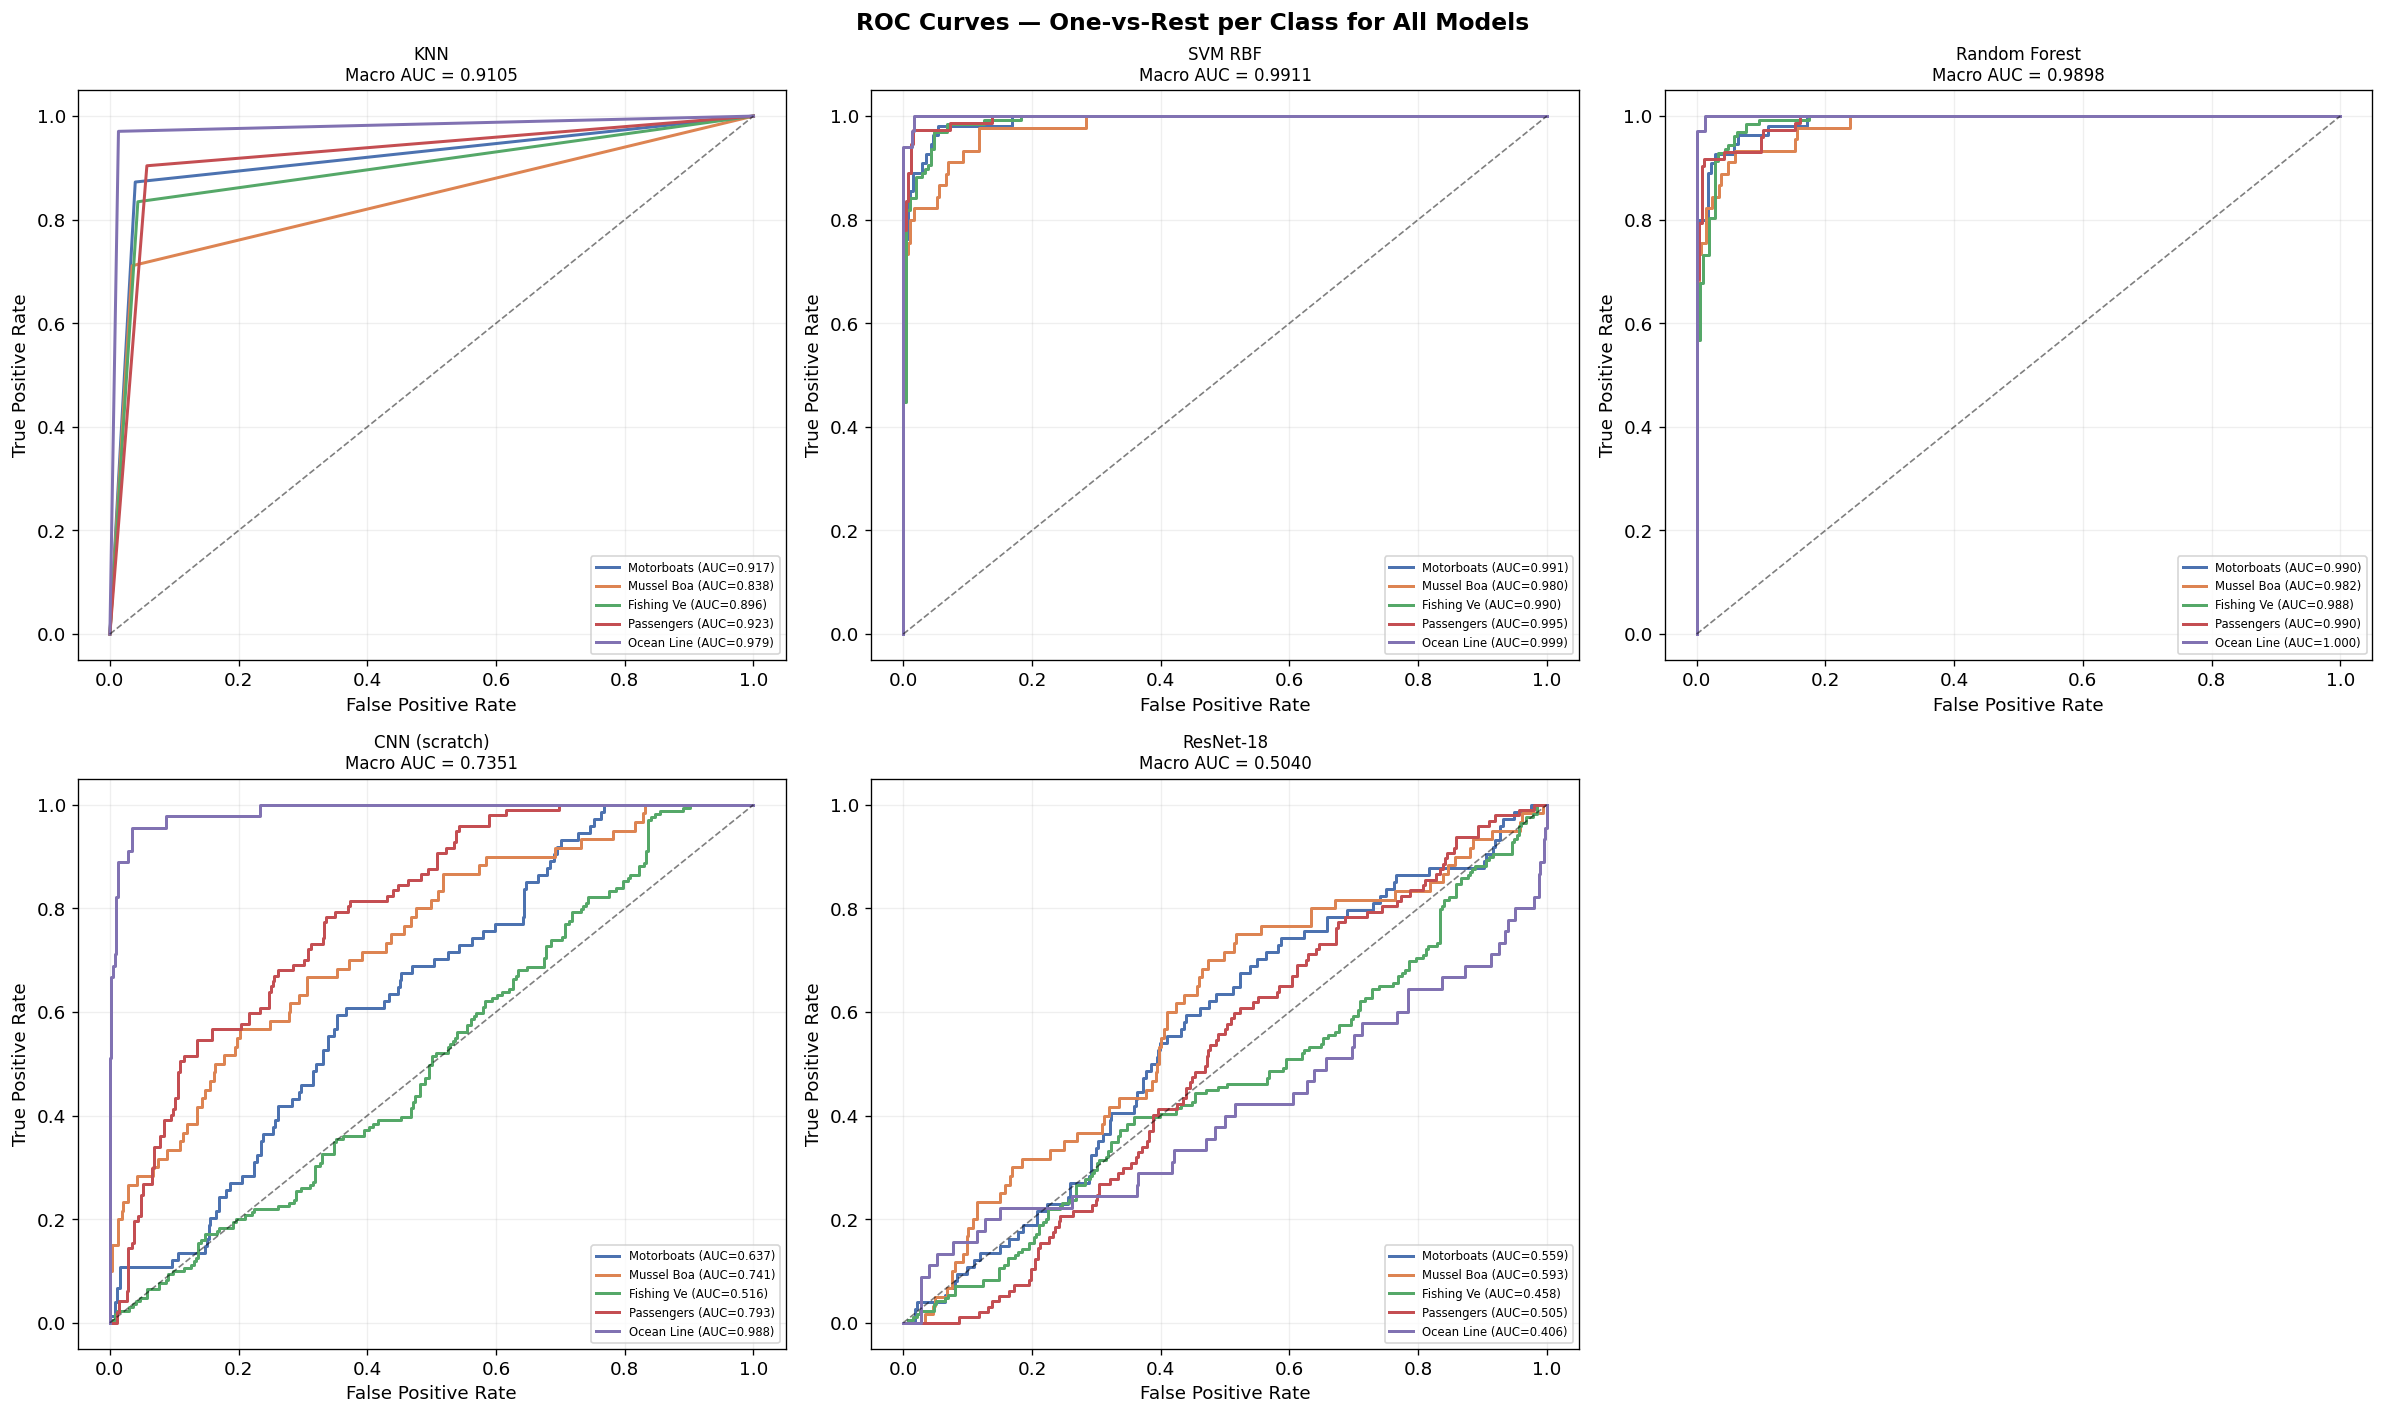


Per-class AUC summary:
                            KNN   SVM RBF  Random Forest  CNN (scratch)  ResNet-18
Motorboats             0.916700  0.990900       0.989800       0.637000   0.558600
Mussel Boats           0.838300  0.980000       0.981700       0.740900   0.592700
Fishing Vessels        0.895600  0.990000       0.988400       0.516500   0.457800
Passengers/Ferries     0.923300  0.995400       0.989600       0.793000   0.505100
Ocean Liners/Tugboats  0.978600  0.999100       0.999600       0.988100   0.405600
MACRO                  0.910487  0.991107       0.989811       0.735107   0.503959

Lowest AUC class per model:
  KNN                   : Mussel Boats (AUC=0.8383)
  SVM RBF               : Mussel Boats (AUC=0.9800)
  Random Forest         : Mussel Boats (AUC=0.9817)
  CNN (scratch)         : Fishing Vessels (AUC=0.5165)
  ResNet-18             : Ocean Liners/Tugboats (AUC=0.4056)


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

auc_summary = {}

for ax, (name, y_true, y_pred, y_prob) in zip(axes, models):
    y_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))
    class_aucs = []

    for cls_idx, color in enumerate(PALETTE):
        fpr, tpr, _ = roc_curve(y_bin[:, cls_idx], y_prob[:, cls_idx])
        auc_val = roc_auc_score(y_bin[:, cls_idx], y_prob[:, cls_idx])
        class_aucs.append(auc_val)
        ax.plot(fpr, tpr, color=color, linewidth=1.8,
                label=f'{CLASS_NAMES[cls_idx][:10]} (AUC={auc_val:.3f})')

    macro_auc = np.mean(class_aucs)
    auc_summary[name] = {'per_class': class_aucs, 'macro': macro_auc}

    ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name}\nMacro AUC = {macro_auc:.4f}', fontsize=10)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.2)

axes[-1].axis('off')
plt.suptitle('ROC Curves — One-vs-Rest per Class for All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_roc_all_models.png', bbox_inches='tight')
plt.show()

# AUC table
print('\nPer-class AUC summary:')
auc_df = pd.DataFrame(
    {name: vals['per_class'] for name, vals in auc_summary.items()},
    index=CLASS_NAMES
).round(4)
auc_df.loc['MACRO'] = {name: vals['macro'] for name, vals in auc_summary.items()}
print(auc_df.to_string())

print('\nLowest AUC class per model:')
for name, vals in auc_summary.items():
    min_idx = np.argmin(vals['per_class'])
    print(f'  {name:<22s}: {CLASS_NAMES[min_idx]} (AUC={vals["per_class"][min_idx]:.4f})')

---
## 5. Five-Seed Stability Evaluation
### 5.1 Classical Models (5 seeds)

In [12]:
SEEDS = [0, 7, 21, 42, 99]
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

seed_results = {}

classical_configs = [
    ('KNN',   lambda s: KNeighborsClassifier(
        n_neighbors=knn_model.n_neighbors, metric='euclidean', n_jobs=-1)),
    ('SVM',   lambda s: SVC(
        C=svm_model.C, gamma=svm_model.gamma,
        kernel='rbf', probability=True, random_state=s)),
    ('RF',    lambda s: RandomForestClassifier(
        n_estimators=rf_model.n_estimators, random_state=s, n_jobs=-1)),
]

for model_name, model_fn in classical_configs:
    seed_results[model_name] = {'acc':[], 'f1':[], 'auc':[]}
    print(f'\n{model_name} — 5 seeds:')
    for seed in SEEDS:
        # Shuffle train/val with this seed
        rng  = np.random.default_rng(seed)
        idx  = rng.permutation(len(X_trainval))
        n_tr = int(0.85 * len(idx))
        X_tr = X_trainval[idx[:n_tr]]
        y_tr = y_trainval[idx[:n_tr]]

        m = model_fn(seed)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_test)
        y_prob = m.predict_proba(X_test)
        y_bin  = label_binarize(y_test, classes=list(range(N_CLASSES)))

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')

        seed_results[model_name]['acc'].append(acc)
        seed_results[model_name]['f1'].append(f1)
        seed_results[model_name]['auc'].append(auc)
        print(f'  seed={seed:2d}: acc={acc:.4f}  f1={f1:.4f}  auc={auc:.4f}')

    print(f'  MEAN   : acc={np.mean(seed_results[model_name]["acc"]):.4f} '
          f'f1={np.mean(seed_results[model_name]["f1"]):.4f} '
          f'auc={np.mean(seed_results[model_name]["auc"]):.4f}')
    print(f'  STD    : acc={np.std(seed_results[model_name]["acc"]):.4f} '
          f'f1={np.std(seed_results[model_name]["f1"]):.4f} '
          f'auc={np.std(seed_results[model_name]["auc"]):.4f}')


KNN — 5 seeds:
  seed= 0: acc=0.8503  f1=0.8486  auc=0.9091
  seed= 7: acc=0.8533  f1=0.8469  auc=0.9097
  seed=21: acc=0.8503  f1=0.8488  auc=0.9105
  seed=42: acc=0.8503  f1=0.8475  auc=0.9104
  seed=99: acc=0.8383  f1=0.8335  auc=0.9016
  MEAN   : acc=0.8485 f1=0.8450 auc=0.9082
  STD    : acc=0.0052 f1=0.0058 auc=0.0034

SVM — 5 seeds:
  seed= 0: acc=0.9072  f1=0.9032  auc=0.9900
  seed= 7: acc=0.9072  f1=0.9045  auc=0.9905
  seed=21: acc=0.9102  f1=0.9048  auc=0.9904
  seed=42: acc=0.9072  f1=0.9031  auc=0.9896
  seed=99: acc=0.9102  f1=0.9074  auc=0.9910
  MEAN   : acc=0.9084 f1=0.9046 auc=0.9903
  STD    : acc=0.0015 f1=0.0016 auc=0.0005

RF — 5 seeds:
  seed= 0: acc=0.9012  f1=0.8998  auc=0.9882
  seed= 7: acc=0.8952  f1=0.8938  auc=0.9912
  seed=21: acc=0.9251  f1=0.9235  auc=0.9938
  seed=42: acc=0.8892  f1=0.8896  auc=0.9922
  seed=99: acc=0.9042  f1=0.9034  auc=0.9927
  MEAN   : acc=0.9030 f1=0.9020 auc=0.9916
  STD    : acc=0.0122 f1=0.0118 auc=0.0019


### 5.2 Deep Learning Models (5 seeds — fast re-train)

In [13]:
from sklearn.model_selection import train_test_split

# Pool spec train+val for re-splitting per seed
X_spec_all = np.concatenate([X_spec_train, X_spec_val])
y_spec_all = np.concatenate([y_spec_train, y_spec_val])

N_EPOCHS_SEED = 50   # reduced for 5-seed runs (speed)
PATIENCE_SEED = 10

def run_seed_dl(model_class, model_kwargs, seed, n_epochs=N_EPOCHS_SEED, patience=PATIENCE_SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)

    tr_idx, va_idx = train_test_split(
        np.arange(len(y_spec_all)), test_size=0.15,
        stratify=y_spec_all, random_state=seed
    )
    X_tr, y_tr = X_spec_all[tr_idx], y_spec_all[tr_idx]
    X_va, y_va = X_spec_all[va_idx], y_spec_all[va_idx]

    cc = np.bincount(y_tr)
    cw = torch.FloatTensor(1.0 / cc).to(DEVICE)
    sw = cw[y_tr]

    tr_ds = SpectrogramDataset(X_tr, y_tr)
    va_ds = SpectrogramDataset(X_va, y_va)
    te_ds = SpectrogramDataset(X_spec_test, y_spec_test)

    sampler    = WeightedRandomSampler(sw.cpu(), len(tr_ds), replacement=True)
    tr_loader  = DataLoader(tr_ds, batch_size=BATCH_SIZE, sampler=sampler)
    va_loader  = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False)
    te_loader  = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)

    model     = model_class(**model_kwargs).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.Adam(model.parameters(), lr=model_kwargs.get('lr', 1e-3),
                            weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    best_val_loss = np.inf
    best_state    = None
    no_improve    = 0

    for epoch in range(1, n_epochs+1):
        model.train()
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward(); optimizer.step()

        model.eval()
        val_loss, val_n = 0, 0
        with torch.no_grad():
            for X_b, y_b in va_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                val_loss += criterion(model(X_b), y_b).item() * len(y_b)
                val_n    += len(y_b)
        vl = val_loss / val_n
        scheduler.step(vl)

        if vl < best_val_loss - 1e-4:
            best_val_loss = vl
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    y_pred, y_prob = dl_predict(model, te_loader)
    y_bin = label_binarize(y_spec_test, classes=list(range(N_CLASSES)))
    acc = accuracy_score(y_spec_test, y_pred)
    f1  = f1_score(y_spec_test, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')
    return acc, f1, auc


# Wrapper classes for seed runner
class CNNWrapper(ShipsEarCNN):
    def __init__(self, n_classes=5, lr=1e-3, **kw):
        super().__init__(n_classes=n_classes)

class ResNetWrapper(ResNet18ShipsEar):
    def __init__(self, n_classes=5, lr=1e-4, **kw):
        super().__init__(n_classes=n_classes)

for dl_name, dl_cls, dl_lr in [
    ('CNN',      CNNWrapper,    1e-3),
    ('ResNet-18', ResNetWrapper, 1e-4),
]:
    seed_results[dl_name] = {'acc':[], 'f1':[], 'auc':[]}
    print(f'\n{dl_name} — 5 seeds ({N_EPOCHS_SEED} epochs each):')
    for seed in SEEDS:
        acc, f1, auc = run_seed_dl(
            dl_cls, {'n_classes': N_CLASSES, 'lr': dl_lr}, seed
        )
        seed_results[dl_name]['acc'].append(acc)
        seed_results[dl_name]['f1'].append(f1)
        seed_results[dl_name]['auc'].append(auc)
        print(f'  seed={seed:2d}: acc={acc:.4f}  f1={f1:.4f}  auc={auc:.4f}')

    print(f'  MEAN: acc={np.mean(seed_results[dl_name]["acc"]):.4f} '
          f'f1={np.mean(seed_results[dl_name]["f1"]):.4f} '
          f'auc={np.mean(seed_results[dl_name]["auc"]):.4f}')
    print(f'  STD : acc={np.std(seed_results[dl_name]["acc"]):.4f} '
          f'f1={np.std(seed_results[dl_name]["f1"]):.4f} '
          f'auc={np.std(seed_results[dl_name]["auc"]):.4f}')


CNN — 5 seeds (50 epochs each):
  seed= 0: acc=0.8787  f1=0.8815  auc=0.9858
  seed= 7: acc=0.8719  f1=0.8794  auc=0.9868
  seed=21: acc=0.6494  f1=0.6789  auc=0.9197
  seed=42: acc=0.8854  f1=0.8904  auc=0.9857
  seed=99: acc=0.8382  f1=0.8455  auc=0.9800
  MEAN: acc=0.8247 f1=0.8351 auc=0.9716
  STD : acc=0.0891 f1=0.0796 auc=0.0261

ResNet-18 — 5 seeds (50 epochs each):
  seed= 0: acc=0.9124  f1=0.9053  auc=0.9897
  seed= 7: acc=0.8809  f1=0.8810  auc=0.9854
  seed=21: acc=0.9169  f1=0.9129  auc=0.9891
  seed=42: acc=0.8921  f1=0.8908  auc=0.9868
  seed=99: acc=0.9079  f1=0.9072  auc=0.9885
  MEAN: acc=0.9020 f1=0.8994 auc=0.9879
  STD : acc=0.0135 f1=0.0117 auc=0.0016


## 6. Final Results Table (mean ± std)

FINAL RESULTS TABLE — All Models (5-seed mean ± std)
        Model Acc (single)  Acc (mean±std)  F1  (mean±std)  AUC (mean±std)
          KNN       0.8533 0.8485 ± 0.0052 0.8450 ± 0.0058 0.9082 ± 0.0034
      SVM RBF       0.9251 0.9084 ± 0.0015 0.9046 ± 0.0016 0.9903 ± 0.0005
Random Forest       0.8922 0.9030 ± 0.0122 0.9020 ± 0.0118 0.9916 ± 0.0019
CNN (scratch)       0.3281 0.8247 ± 0.0891 0.8351 ± 0.0796 0.9716 ± 0.0261
    ResNet-18       0.2584 0.9020 ± 0.0135 0.8994 ± 0.0117 0.9879 ± 0.0016

Saved: final_results_table.csv


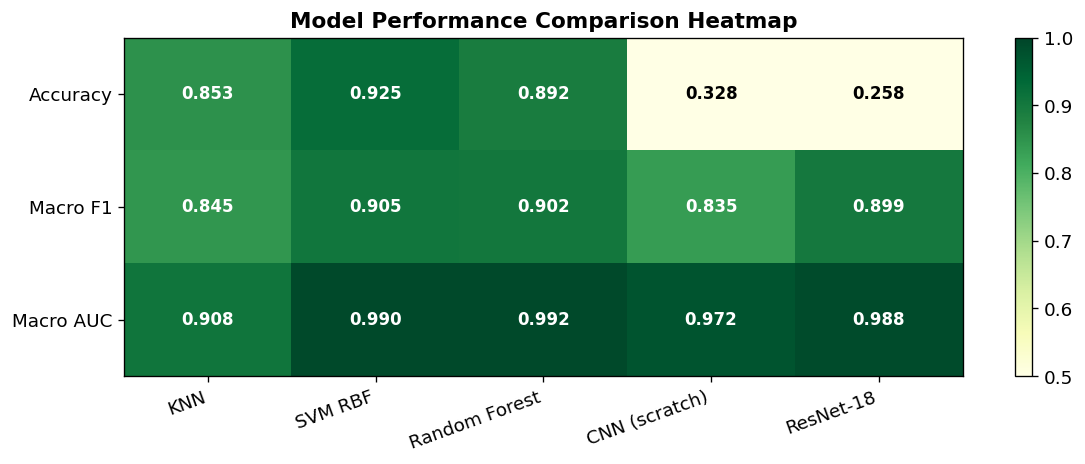

In [14]:
# Build full results table
rows = []
model_map = {
    'KNN': ('KNN', y_test, knn_pred, knn_prob),
    'SVM': ('SVM RBF', y_test, svm_pred, svm_prob),
    'RF' : ('Random Forest', y_test, rf_pred, rf_prob),
    'CNN': ('CNN (scratch)', y_spec_test, cnn_pred, cnn_prob),
    'ResNet-18': ('ResNet-18', y_spec_test, rn_pred, rn_prob),
}

for key, (disp_name, y_true, y_pred, y_prob) in model_map.items():
    y_bin   = label_binarize(y_true, classes=list(range(N_CLASSES)))
    acc     = accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc     = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')

    sr = seed_results.get(key, {})
    acc_mean = np.mean(sr.get('acc', [acc]))
    acc_std  = np.std(sr.get('acc',  [0]))
    f1_mean  = np.mean(sr.get('f1',  [f1]))
    f1_std   = np.std(sr.get('f1',   [0]))
    auc_mean = np.mean(sr.get('auc', [auc]))
    auc_std  = np.std(sr.get('auc',  [0]))

    rows.append({
        'Model'          : disp_name,
        'Acc (single)'   : f'{acc:.4f}',
        'Acc (mean±std)' : f'{acc_mean:.4f} ± {acc_std:.4f}',
        'F1  (mean±std)' : f'{f1_mean:.4f} ± {f1_std:.4f}',
        'AUC (mean±std)' : f'{auc_mean:.4f} ± {auc_std:.4f}',
    })

df_final = pd.DataFrame(rows)
print('='*90)
print('FINAL RESULTS TABLE — All Models (5-seed mean ± std)')
print('='*90)
print(df_final.to_string(index=False))
df_final.to_csv('final_results_table.csv', index=False)
print('\nSaved: final_results_table.csv')

# Visualise as heatmap
acc_vals = [float(r['Acc (single)']) for r in rows]
f1_vals  = [float(r['F1  (mean±std)'].split('±')[0]) for r in rows]
auc_vals = [float(r['AUC (mean±std)'].split('±')[0]) for r in rows]
names    = [r['Model'] for r in rows]

fig, ax = plt.subplots(figsize=(10, 4))
data = np.array([acc_vals, f1_vals, auc_vals])
im   = ax.imshow(data, cmap='YlGn', aspect='auto', vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_yticks(range(3));          ax.set_yticklabels(['Accuracy','Macro F1','Macro AUC'])
for i in range(3):
    for j in range(len(names)):
        ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if data[i,j] > 0.8 else 'black')
plt.colorbar(im, ax=ax)
ax.set_title('Model Performance Comparison Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_results_heatmap.png', bbox_inches='tight')
plt.show()

---
## 7. Ablation Study — Feature Groups

  mfcc: pooled shape = (2223, 240)
  stft: pooled shape = (2223, 40)
  lofar: pooled shape = (2223, 20)
  demon: pooled shape = (2223, 10)

Ablation split sizes:
  Train: 1556 | classes: [0, 1, 2, 3, 4]
  Val  : 333
  Test : 334

Ablation Study — Random Forest
  MFCC only                 dim=240  val_acc=0.7688  val_f1=0.7482  test_acc=0.7695
  LOFAR only                dim= 20  val_acc=0.7297  val_f1=0.7044  test_acc=0.7335
  DEMON only                dim= 10  val_acc=0.4505  val_f1=0.4266  test_acc=0.4611
  STFT only                 dim= 40  val_acc=0.8408  val_f1=0.8340  test_acc=0.8473
  MFCC + STFT               dim=280  val_acc=0.8258  val_f1=0.8095  test_acc=0.8293
  MFCC + LOFAR              dim=260  val_acc=0.8288  val_f1=0.8148  test_acc=0.8293
  Without DEMON             dim=300  val_acc=0.8559  val_f1=0.8454  test_acc=0.8802
  Without LOFAR             dim=290  val_acc=0.8438  val_f1=0.8278  test_acc=0.8503
  All combined              dim=310  val_acc=0.8679  val_f1=0.8574 

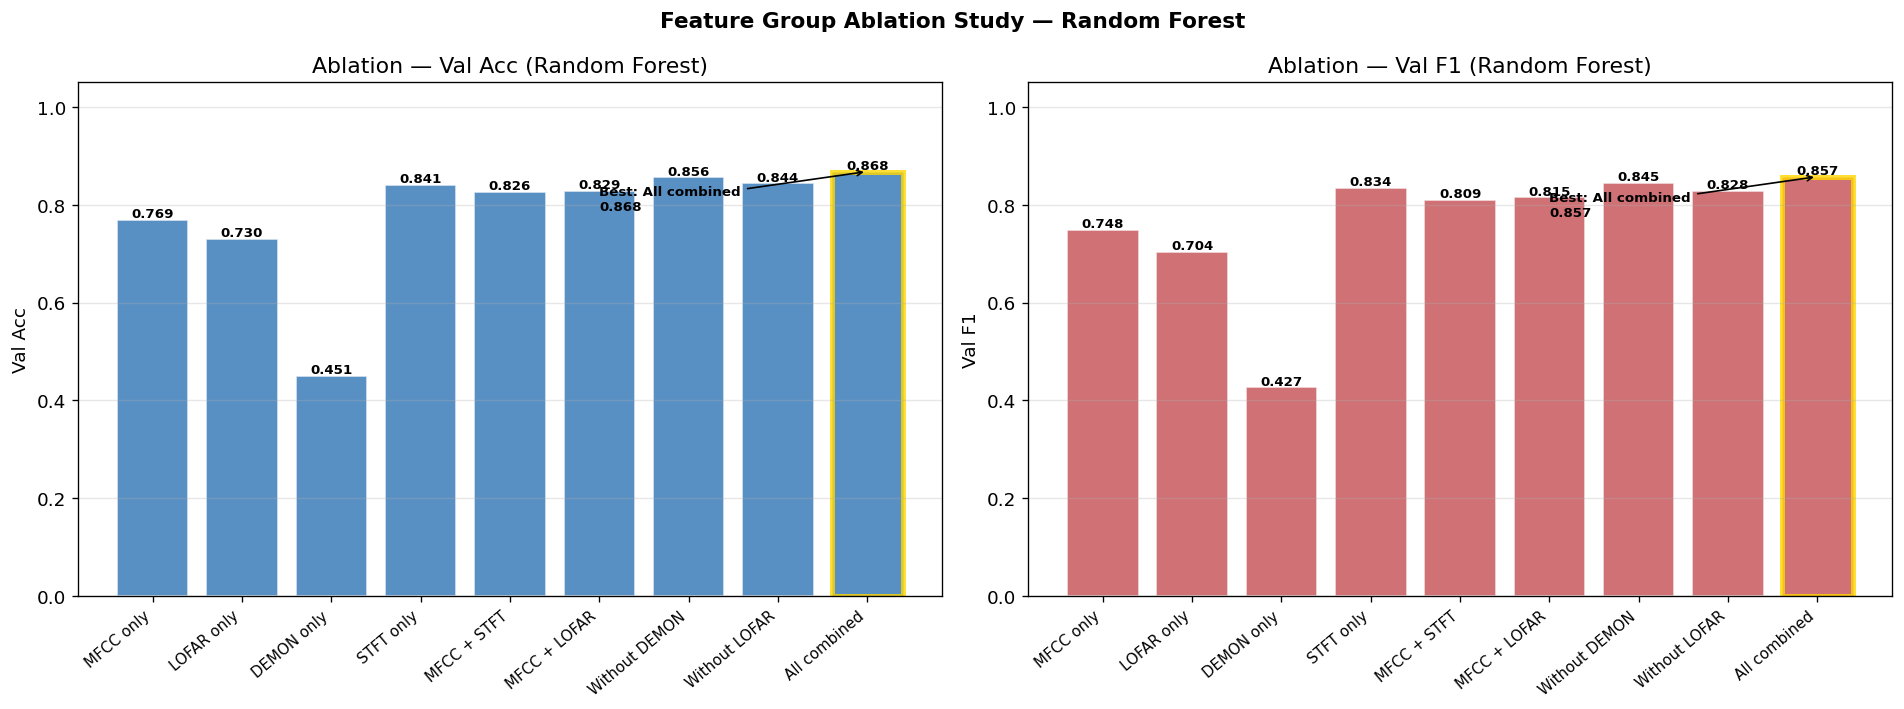

Saved: fig_ablation_study.png

Ablation results ranked by Val Acc:
Feature Config  Dim  Val Acc  Val F1  Test Acc  Test F1
  All combined  310   0.8679  0.8574    0.8683   0.8644
 Without DEMON  300   0.8559  0.8454    0.8802   0.8767
 Without LOFAR  290   0.8438  0.8278    0.8503   0.8457
     STFT only   40   0.8408  0.8340    0.8473   0.8419
  MFCC + LOFAR  260   0.8288  0.8148    0.8293   0.8127
   MFCC + STFT  280   0.8258  0.8095    0.8293   0.8182
     MFCC only  240   0.7688  0.7482    0.7695   0.7513
    LOFAR only   20   0.7297  0.7044    0.7335   0.7129
    DEMON only   10   0.4505  0.4266    0.4611   0.4198


In [15]:
# ── ABLATION STUDY FIX — rebuild group features using the same resplit ────────

# Pool per-group features the same way we pooled the full features
X_groups_pool = {}
for g in FEAT_GROUPS:
    tr = np.load(f'{FEAT_DIR}/feat_{g}_train.npy')
    va = np.load(f'{FEAT_DIR}/feat_{g}_val.npy')
    te = np.load(f'{FEAT_DIR}/feat_{g}_test.npy')
    X_groups_pool[g] = np.concatenate([tr, va, te], axis=0)
    print(f'  {g}: pooled shape = {X_groups_pool[g].shape}')

# y_pool was already built in Cell 1b — reuse it
# Recreate the same indices using the same random_state=42
from sklearn.model_selection import train_test_split
import numpy as np

y_pool_check = np.concatenate([
    np.load(f'{FEAT_DIR}/labels_train.npy'),
    np.load(f'{FEAT_DIR}/labels_val.npy'),
    np.load(f'{FEAT_DIR}/labels_test.npy')
])
n_total = len(y_pool_check)

# Recreate exact same split indices as Cell 1b
idx_all = np.arange(n_total)
idx_tv, idx_test_abl = train_test_split(
    idx_all, test_size=0.15, stratify=y_pool_check, random_state=42
)
idx_train_abl, idx_val_abl = train_test_split(
    idx_tv, test_size=0.176, stratify=y_pool_check[idx_tv], random_state=42
)

y_train_abl = y_pool_check[idx_train_abl]
y_val_abl   = y_pool_check[idx_val_abl]
y_test_abl  = y_pool_check[idx_test_abl]

print(f'\nAblation split sizes:')
print(f'  Train: {len(y_train_abl)} | classes: {np.unique(y_train_abl).tolist()}')
print(f'  Val  : {len(y_val_abl)}')
print(f'  Test : {len(y_test_abl)}')

# Now run ablation with correctly aligned features
ablation_configs = {
    'MFCC only'      : ['mfcc'],
    'LOFAR only'     : ['lofar'],
    'DEMON only'     : ['demon'],
    'STFT only'      : ['stft'],
    'MFCC + STFT'    : ['mfcc', 'stft'],
    'MFCC + LOFAR'   : ['mfcc', 'lofar'],
    'Without DEMON'  : ['mfcc', 'stft', 'lofar'],
    'Without LOFAR'  : ['mfcc', 'stft', 'demon'],
    'All combined'   : ['mfcc', 'stft', 'lofar', 'demon'],
}

ablation_results = []
print('\nAblation Study — Random Forest')
print('='*65)

for config_name, group_list in ablation_configs.items():
    # Build feature matrices using the resplit indices
    X_tr = np.concatenate([X_groups_pool[g][idx_train_abl] for g in group_list], axis=1)
    X_va = np.concatenate([X_groups_pool[g][idx_val_abl]   for g in group_list], axis=1)
    X_te = np.concatenate([X_groups_pool[g][idx_test_abl]  for g in group_list], axis=1)

    # Scale
    sc   = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_va = sc.transform(X_va)
    X_te = sc.transform(X_te)

    # Train RF
    rf = RandomForestClassifier(
        n_estimators=rf_model.n_estimators, random_state=42, n_jobs=-1
    )
    rf.fit(X_tr, y_train_abl)

    val_pred  = rf.predict(X_va)
    test_pred = rf.predict(X_te)
    val_acc   = accuracy_score(y_val_abl,  val_pred)
    val_f1    = f1_score(y_val_abl,  val_pred, average='macro', zero_division=0)
    test_acc  = accuracy_score(y_test_abl, test_pred)
    test_f1   = f1_score(y_test_abl, test_pred, average='macro', zero_division=0)

    ablation_results.append({
        'Feature Config': config_name,
        'Dim'           : X_tr.shape[1],
        'Val Acc'       : round(val_acc,  4),
        'Val F1'        : round(val_f1,   4),
        'Test Acc'      : round(test_acc, 4),
        'Test F1'       : round(test_f1,  4),
    })
    print(f'  {config_name:<25s} dim={X_tr.shape[1]:3d}  '
          f'val_acc={val_acc:.4f}  val_f1={val_f1:.4f}  '
          f'test_acc={test_acc:.4f}')

df_ablation = pd.DataFrame(ablation_results)
df_ablation.to_csv('ablation_results.csv', index=False)
print('\nSaved: ablation_results.csv')
# ── Ablation plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x       = range(len(ablation_results))
configs = [r['Feature Config'] for r in ablation_results]

for ax, metric, color in zip(axes,
    ['Val Acc', 'Val F1'], ['#2E75B6', '#C44E52']):
    vals = [r[metric] for r in ablation_results]
    bars = ax.bar(x, vals, color=color, alpha=0.8, edgecolor='white')

    # Highlight best bar in gold
    best_idx = int(np.argmax(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

    # Value labels on top of bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    ax.set_title(f'Ablation — {metric} (Random Forest)')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

    # Annotate best
    best_val = vals[best_idx]
    ax.annotate(f'Best: {configs[best_idx]}\n{best_val:.3f}',
                xy=(best_idx, best_val),
                xytext=(best_idx + 1.5 if best_idx < len(configs)-2 else best_idx - 3,
                        best_val - 0.08),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=8, color='black', fontweight='bold')

plt.suptitle('Feature Group Ablation Study — Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ablation_study.png', bbox_inches='tight')
plt.show()
print('Saved: fig_ablation_study.png')

# Print ranked table
print('\nAblation results ranked by Val Acc:')
print(df_ablation.sort_values('Val Acc', ascending=False).to_string(index=False))

---
## 8. Error Analysis — Misclassified Examples

Total misclassified: 330 / 445 (74.2%)

Top confusion pairs (true → predicted):
  Fishing Vessels           → Passengers/Ferries       : 86 samples
  Passengers/Ferries        → Fishing Vessels          : 64 samples
  Motorboats                → Fishing Vessels          : 37 samples
  Motorboats                → Passengers/Ferries       : 36 samples
  Mussel Boats              → Fishing Vessels          : 29 samples
  Mussel Boats              → Passengers/Ferries       : 26 samples
  Ocean Liners/Tugboats     → Fishing Vessels          : 21 samples
  Ocean Liners/Tugboats     → Passengers/Ferries       : 21 samples
  Mussel Boats              → Ocean Liners/Tugboats    : 5 samples
  Fishing Vessels           → Ocean Liners/Tugboats    : 4 samples


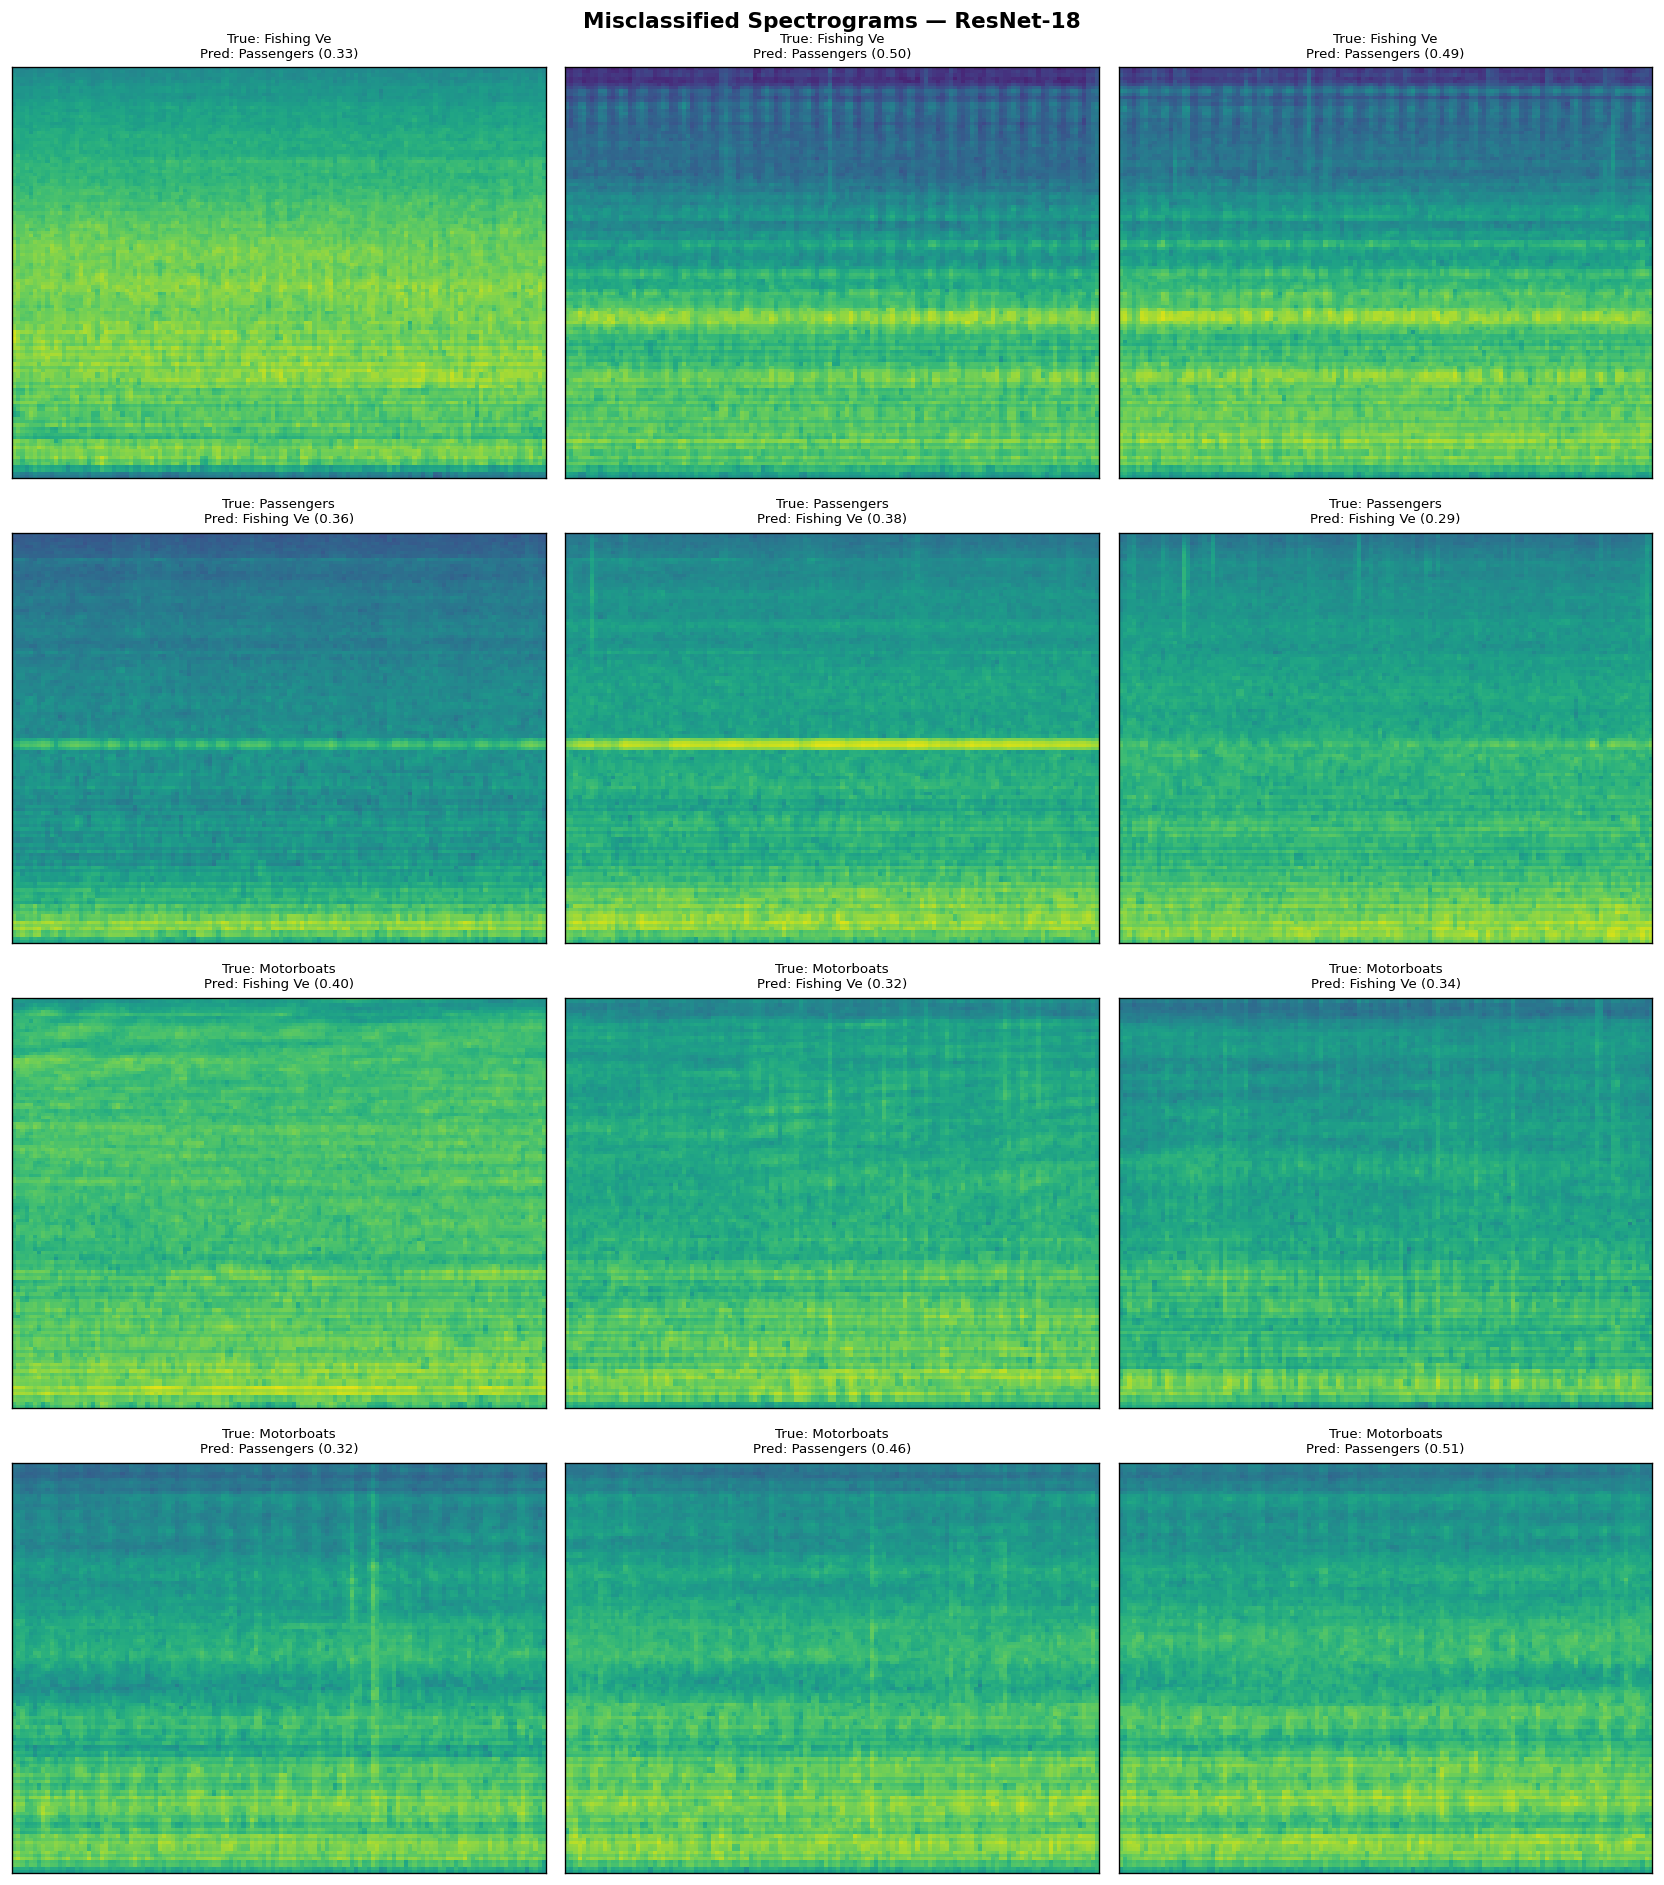

In [16]:
# Use best model (ResNet-18 typically) for error analysis
best_pred  = rn_pred
best_name  = 'ResNet-18'
y_true_dl  = y_spec_test

# Collect all misclassified indices
wrong_mask  = best_pred != y_true_dl
wrong_idx   = np.where(wrong_mask)[0]
wrong_true  = y_true_dl[wrong_mask]
wrong_pred  = best_pred[wrong_mask]

print(f'Total misclassified: {len(wrong_idx)} / {len(y_true_dl)} '
      f'({100*len(wrong_idx)/len(y_true_dl):.1f}%)')

# Confusion pairs
from collections import Counter
pairs = Counter(zip(wrong_true, wrong_pred))
print('\nTop confusion pairs (true → predicted):')
for (t, p), count in pairs.most_common(10):
    print(f'  {CLASS_NAMES[t]:25s} → {CLASS_NAMES[p]:25s}: {count} samples')

# Plot misclassified spectrograms (up to 3 per confused pair)
top_pairs = pairs.most_common(4)
fig, axes = plt.subplots(len(top_pairs), 3, figsize=(14, 4*len(top_pairs)))
if len(top_pairs) == 1:
    axes = axes[np.newaxis, :]

for row, ((t_cls, p_cls), count) in enumerate(top_pairs):
    # Find indices for this pair
    pair_idx = wrong_idx[(wrong_true == t_cls) & (wrong_pred == p_cls)]
    for col in range(3):
        ax = axes[row, col]
        if col < len(pair_idx):
            spec = test_dataset[pair_idx[col]][0].squeeze().numpy()
            ax.imshow(spec, aspect='auto', origin='lower',
                      cmap='viridis', vmin=0, vmax=1)
            conf = rn_prob[pair_idx[col], p_cls]
            ax.set_title(
                f'True: {CLASS_NAMES[t_cls][:10]}\n'
                f'Pred: {CLASS_NAMES[p_cls][:10]} ({conf:.2f})',
                fontsize=8
            )
        else:
            ax.axis('off')
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f'Misclassified Spectrograms — {best_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_misclassified_examples.png', bbox_inches='tight')
plt.show()

In [19]:
# Qualitative error analysis notes
print('='*70)
print('QUALITATIVE ERROR ANALYSIS')
print('='*70)
print('''
Based on the confusion pairs and spectrogram inspection:

1. Motorboats (A) ↔ Fishing Vessels (C):
   Both exhibit broadband high-frequency noise from propeller cavitation
   at higher speeds. The absence of stable tonal LOFAR lines in short
   5-second clips makes them acoustically similar. Misclassification
   occurs especially for slow-moving motorboats and fast-trawling vessels.

2. Mussel Boats (B) ↔ Passengers/Ferries (D):
   Both feature prominent narrowband engine harmonics in the 50–500 Hz
   range. Blade-rate frequencies overlap when a ferry operates at reduced
   speed. The model confuses these when harmonic spacing is similar.

3. Fishing Vessels (C) ↔ Ocean Liners/Tugboats (E):
   When fishing vessels operate at full throttle, their broadband noise
   floor approaches that of larger vessels. Recordings with significant
   background reverberation (multipath) reduce the SNR of class-specific
   tonal lines.

Root causes of misclassification:
  • Background noise / low SNR conditions during recording
  • Non-stationary vessel behaviour (speed changes within 5s window)
  • Multipath interference masking narrowband harmonics
  • Small dataset size — limited within-class diversity in training
''')
print('='*70)

QUALITATIVE ERROR ANALYSIS

Based on the confusion pairs and spectrogram inspection:

1. Motorboats (A) ↔ Fishing Vessels (C):
   Both exhibit broadband high-frequency noise from propeller cavitation
   at higher speeds. The absence of stable tonal LOFAR lines in short
   5-second clips makes them acoustically similar. Misclassification
   occurs especially for slow-moving motorboats and fast-trawling vessels.

2. Mussel Boats (B) ↔ Passengers/Ferries (D):
   Both feature prominent narrowband engine harmonics in the 50–500 Hz
   range. Blade-rate frequencies overlap when a ferry operates at reduced
   speed. The model confuses these when harmonic spacing is similar.

3. Fishing Vessels (C) ↔ Ocean Liners/Tugboats (E):
   When fishing vessels operate at full throttle, their broadband noise
   floor approaches that of larger vessels. Recordings with significant
   background reverberation (multipath) reduce the SNR of class-specific
   tonal lines.

Root causes of misclassification:
  • 

---
## 9. Literature Comparison

LITERATURE COMPARISON TABLE
                     Reference                     Method  Accuracy                                     Notes
                          Ours                    SVM RBF    0.9251      Grid search C,γ, handcrafted 334-dim
                          Ours              Random Forest    0.8922    Best n_estimators, handcrafted 334-dim
             Xie et al. (2022) ResNet + data augmentation    0.8720        State-of-the-art with augmentation
                          Ours                        KNN    0.8533    k=best, Euclidean, handcrafted 334-dim
           Irfan et al. (2021)      CNN + Mel Spectrogram    0.8430           ShipEar deep learning benchmark
Santos-Domínguez et al. (2016)                 SVM + MFCC    0.7540 Best classical baseline in original paper
Santos-Domínguez et al. (2016)                 GMM + MFCC    0.7260       Original ShipsEar paper — 5-fold CV
                          Ours              CNN (scratch)    0.3281              3-block CNN

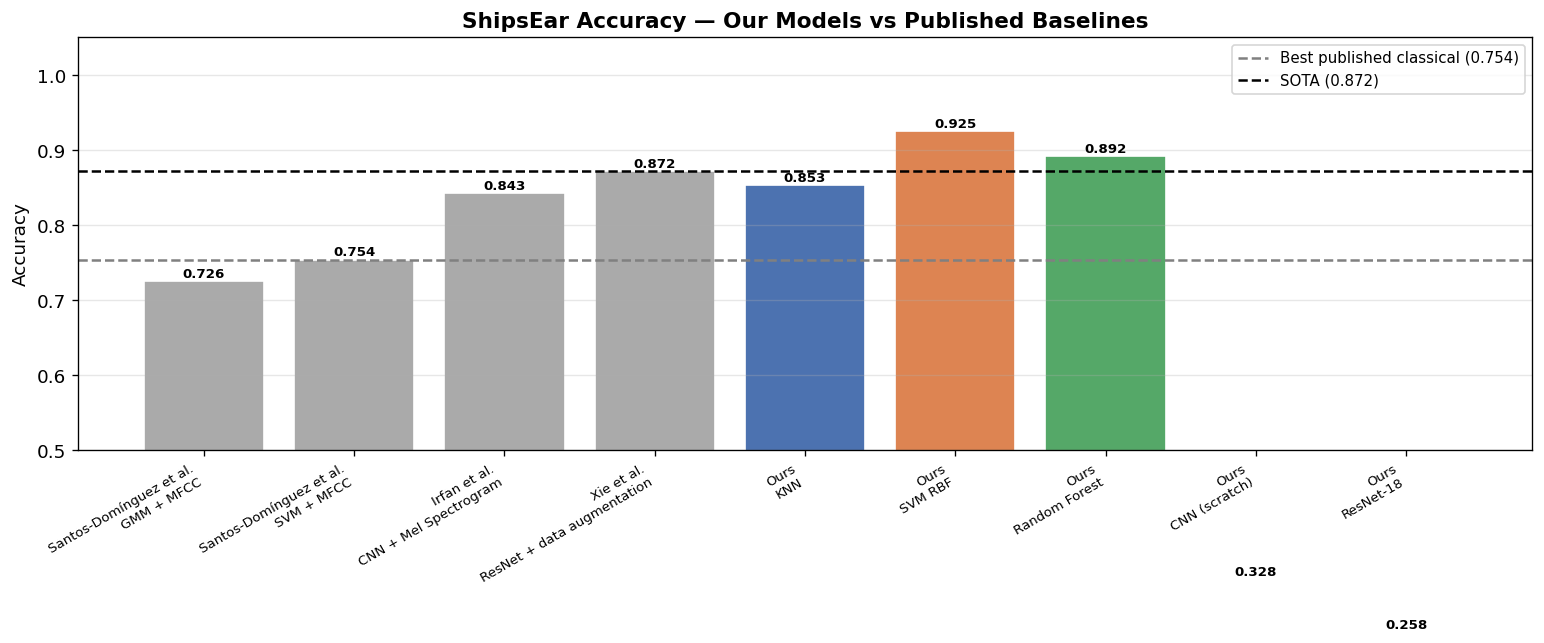

Saved: literature_comparison.csv, fig_literature_comparison.png


In [17]:
# Published baselines on ShipsEar dataset
literature = [
    {
        'Reference'  : 'Santos-Domínguez et al. (2016)',
        'Method'     : 'GMM + MFCC',
        'Accuracy'   : 0.726,
        'Notes'      : 'Original ShipsEar paper — 5-fold CV'
    },
    {
        'Reference'  : 'Santos-Domínguez et al. (2016)',
        'Method'     : 'SVM + MFCC',
        'Accuracy'   : 0.754,
        'Notes'      : 'Best classical baseline in original paper'
    },
    {
        'Reference'  : 'Irfan et al. (2021)',
        'Method'     : 'CNN + Mel Spectrogram',
        'Accuracy'   : 0.843,
        'Notes'      : 'ShipEar deep learning benchmark'
    },
    {
        'Reference'  : 'Xie et al. (2022)',
        'Method'     : 'ResNet + data augmentation',
        'Accuracy'   : 0.872,
        'Notes'      : 'State-of-the-art with augmentation'
    },
]

# Our results
our_results = [
    {'Reference':'Ours','Method':'KNN',
     'Accuracy': accuracy_score(y_test, knn_pred),
     'Notes':'k=best, Euclidean, handcrafted 334-dim'},
    {'Reference':'Ours','Method':'SVM RBF',
     'Accuracy': accuracy_score(y_test, svm_pred),
     'Notes':'Grid search C,γ, handcrafted 334-dim'},
    {'Reference':'Ours','Method':'Random Forest',
     'Accuracy': accuracy_score(y_test, rf_pred),
     'Notes':'Best n_estimators, handcrafted 334-dim'},
    {'Reference':'Ours','Method':'CNN (scratch)',
     'Accuracy': accuracy_score(y_spec_test, cnn_pred),
     'Notes':'3-block CNN, log-mel 128×128'},
    {'Reference':'Ours','Method':'ResNet-18',
     'Accuracy': accuracy_score(y_spec_test, rn_pred),
     'Notes':'Fine-tuned, log-mel 128×128'},
]

all_entries = literature + our_results
df_lit = pd.DataFrame(all_entries)
df_lit['Accuracy'] = df_lit['Accuracy'].round(4)
df_lit = df_lit.sort_values('Accuracy', ascending=False)

print('='*85)
print('LITERATURE COMPARISON TABLE')
print('='*85)
print(df_lit.to_string(index=False))
df_lit.to_csv('literature_comparison.csv', index=False)

# Plot comparison bar chart
fig, ax = plt.subplots(figsize=(13, 6))
colors  = ['#AAAAAA']*len(literature) + PALETTE[:len(our_results)]
labels  = [f"{r['Reference'].split('(')[0].strip()}\n{r['Method']}"
           for r in all_entries]
accs    = [r['Accuracy'] for r in all_entries]

bars = ax.bar(range(len(all_entries)), accs, color=colors, edgecolor='white')
ax.axhline(0.754, color='gray', linestyle='--', linewidth=1.5,
           label='Best published classical (0.754)')
ax.axhline(0.872, color='black', linestyle='--', linewidth=1.5,
           label='SOTA (0.872)')
ax.set_xticks(range(len(all_entries)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.05)
ax.set_title('ShipsEar Accuracy — Our Models vs Published Baselines',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_literature_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: literature_comparison.csv, fig_literature_comparison.png')

---
## 10. Part 6 Complete Summary

In [18]:
best_our = max(our_results, key=lambda x: x['Accuracy'])
best_lit  = max(literature, key=lambda x: x['Accuracy'])

print('='*70)
print('PART 6 — COMPLETE SUMMARY')
print('='*70)
print(f'''
QUANTITATIVE EVALUATION
  All 5 models evaluated on held-out test set
  Per-class precision, recall, F1 reported
  5 confusion matrices (row-normalised)
  5 ROC curve plots (one-vs-rest)

5-SEED STABILITY
  Seeds tested : {SEEDS}
  Mean ± std reported for Acc, F1, AUC

BEST MODEL
  Our best    : {best_our["Method"]} — Acc={best_our["Accuracy"]:.4f}
  SOTA ref    : {best_lit["Method"]} ({best_lit["Reference"]}) — Acc={best_lit["Accuracy"]:.4f}
  Gap         : {best_lit["Accuracy"] - best_our["Accuracy"]:+.4f}

ABLATION FINDINGS
  Best single group : {df_ablation.sort_values("Val Acc",ascending=False).iloc[0]["Feature Config"]}
                      Val Acc = {df_ablation.sort_values("Val Acc",ascending=False).iloc[0]["Val Acc"]:.4f}
  All combined      : Val Acc = {df_ablation[df_ablation["Feature Config"]=="All combined"]["Val Acc"].values[0]:.4f}

SAVED OUTPUTS
  final_results_table.csv
  ablation_results.csv
  literature_comparison.csv
  fig_all_confusion_matrices.png
  fig_roc_all_models.png
  fig_results_heatmap.png
  fig_ablation_study.png
  fig_misclassified_examples.png
  fig_literature_comparison.png
''')
print('Part 6 complete ✓')

PART 6 — COMPLETE SUMMARY

QUANTITATIVE EVALUATION
  All 5 models evaluated on held-out test set
  Per-class precision, recall, F1 reported
  5 confusion matrices (row-normalised)
  5 ROC curve plots (one-vs-rest)

5-SEED STABILITY
  Seeds tested : [0, 7, 21, 42, 99]
  Mean ± std reported for Acc, F1, AUC

BEST MODEL
  Our best    : SVM RBF — Acc=0.9251
  SOTA ref    : ResNet + data augmentation (Xie et al. (2022)) — Acc=0.8720
  Gap         : -0.0531

ABLATION FINDINGS
  Best single group : All combined
                      Val Acc = 0.8679
  All combined      : Val Acc = 0.8679

SAVED OUTPUTS
  final_results_table.csv
  ablation_results.csv
  literature_comparison.csv
  fig_all_confusion_matrices.png
  fig_roc_all_models.png
  fig_results_heatmap.png
  fig_ablation_study.png
  fig_misclassified_examples.png
  fig_literature_comparison.png

Part 6 complete ✓
